# CS229 in Practice: Generalized Linear Models (GLMs)

**Concept implemented:** Generalized Linear Models — Chapter 3 of the CS229 notes.

**Core idea from the theory:** linear regression and logistic regression are not two unrelated
algorithms. They are both special cases of one GLM recipe:

1. $y\mid x;\theta \sim \text{ExponentialFamily}(\eta)$
2. $h(x) = E[y\mid x]$
3. $\eta = \theta^Tx$ (linear relationship between the natural parameter and the inputs)

- Assume a **Gaussian** response → the recipe produces **ordinary least squares**, $h_\theta(x)=\theta^Tx$.
- Assume a **Bernoulli** response → the recipe produces **logistic regression**,
  $h_\theta(x) = 1/(1+e^{-\theta^Tx})$.

**Dataset:** `heart.csv` — 918 patients, 11 clinical features.

**How we demonstrate GLMs on this dataset:** the dataset contains both a **continuous** target
(`Cholesterol`) and a **binary** target (`HeartDisease`). We fit a GLM for each:

- **Gaussian GLM (regression)** → predict `Cholesterol` with `LinearRegression`.
- **Bernoulli GLM (classification)** → predict `HeartDisease` with `LogisticRegression`.

Both models are $h_\theta(x) = g(\theta^Tx)$ for a different **canonical response function** $g$ — we
build them side by side to make that shared structure concrete, then run an experiment that shows
*why* picking the right exponential-family assumption (the right $g$) matters.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# Rows = number of patients, columns = features + the two targets we will use (Cholesterol, HeartDisease)
df.shape

(918, 12)

In [4]:
# Data types: which columns are numeric vs. categorical text
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
# Check for missing values encoded as NaN
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## 3. Understand the Data

We will use this dataset for **two different GLMs**:

- **Gaussian GLM target:** `Cholesterol` (continuous, mg/dl) — a natural fit for the Gaussian
  exponential-family assumption.
- **Bernoulli GLM target:** `HeartDisease` (0/1) — a natural fit for the Bernoulli assumption.

`df.isnull().sum()` shows no `NaN`s, but `df.describe()` shows a minimum of `0` for both `RestingBP`
and `Cholesterol`, which is not physiologically possible — these are disguised missing values.

In [7]:
print("RestingBP == 0:", (df["RestingBP"] == 0).sum())
print("Cholesterol == 0:", (df["Cholesterol"] == 0).sum())

RestingBP == 0: 1
Cholesterol == 0: 172


> ⚠️ **Data issue:** 172 patients have `Cholesterol = 0` and 1 has `RestingBP = 0`. Since
> `Cholesterol` is itself one of our two GLM targets, rows with `Cholesterol = 0` cannot be used to
> train or evaluate the Gaussian GLM (there is no real label to learn from) — we drop them **only for
> the Cholesterol model**. For the `RestingBP` feature (used in both models), we impute the single
> missing value with the training median, as before.

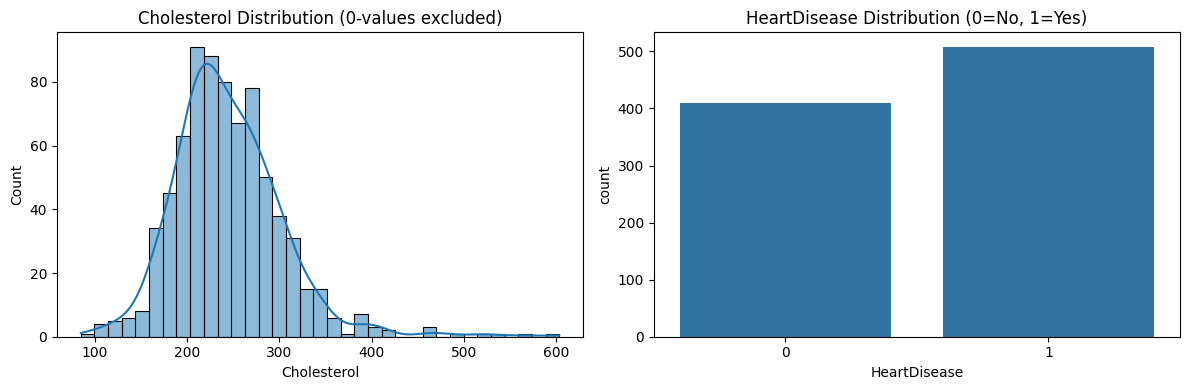

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df[df["Cholesterol"] > 0]["Cholesterol"], kde=True)
plt.title("Cholesterol Distribution (0-values excluded)")

plt.subplot(1, 2, 2)
sns.countplot(x="HeartDisease", data=df)
plt.title("HeartDisease Distribution (0=No, 1=Yes)")

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Shared preprocessing for both models:

1. Fix the disguised missing `RestingBP` value.
2. One-hot encode categorical columns.

Model-specific preprocessing:

- **Gaussian GLM:** drop the 172 rows with `Cholesterol = 0` (invalid label), and predict `Cholesterol`
  from every other column, including `HeartDisease` as a feature this time.
- **Bernoulli GLM:** keep all rows, impute `Cholesterol = 0` as a missing *feature* value with the
  training median (a value of 0 is still informative-ish here as "unknown," but as a feature — not a
  label — imputation is the safer choice rather than discarding 19% of the data).

In [9]:
df_clean = df.copy()
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


## 5. Connect Theory to Code

```text
CS229 Theory (GLM recipe)
      |
1. y | x ~ ExponentialFamily(eta)
      |
2. h(x) = E[y | x]
      |
3. eta = theta^T x
      |
Gaussian  ->  h(x) = theta^T x        ->  sklearn LinearRegression
Bernoulli ->  h(x) = 1/(1+e^-theta^Tx) ->  sklearn LogisticRegression
```

Both `LinearRegression` and `LogisticRegression` fit $\theta$ by maximizing the likelihood of the data
under their respective exponential-family assumption (for `LinearRegression`, maximizing Gaussian
likelihood is equivalent to minimizing squared error — the two are mathematically the same objective).
The only structural difference sklearn's API reflects is the **canonical response function** applied
to $\theta^Tx$: identity for the Gaussian GLM, sigmoid for the Bernoulli GLM.

---
## 6. Part A — Gaussian GLM: Predicting `Cholesterol` (Ordinary Least Squares)

$$
y\mid x;\theta \sim N(\mu,\sigma^2), \qquad h_\theta(x) = E[y\mid x;\theta] = \mu = \eta = \theta^Tx
$$

- $\theta$ → learned regression weights
- $x$ → patient features (excluding `Cholesterol` itself)
- $h_\theta(x)$ → predicted cholesterol level (the mean $\mu$ of the assumed Gaussian)

We drop the 172 rows with an invalid (`0`) `Cholesterol` label — those rows have no real value of the
target variable to learn from.

In [10]:
df_gaussian = df_encoded.dropna(subset=["Cholesterol"]).copy()
print("Rows available for the Gaussian GLM (valid Cholesterol only):", df_gaussian.shape[0])

# Impute the single missing RestingBP value with the median of this subset
df_gaussian["RestingBP"] = df_gaussian["RestingBP"].fillna(df_gaussian["RestingBP"].median())

X_g = df_gaussian.drop(columns=["Cholesterol"])
y_g = df_gaussian["Cholesterol"]

Rows available for the Gaussian GLM (valid Cholesterol only): 746


### Train/Test Split

- `X_g` → all features (including `HeartDisease`) used to predict cholesterol.
- `y_g` → the true `Cholesterol` values.
- We split so that the test set measures how well the model generalizes to patients it never saw during
  training, and never let the test set influence how the model or its preprocessing are fit.

In [11]:
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_g, y_g, test_size=0.2, random_state=RANDOM_STATE
)

print("Training examples:", Xg_train.shape[0])
print("Test examples:", Xg_test.shape[0])

Training examples: 596
Test examples: 150


### Why scale the features?

Ordinary least squares is fit by minimizing squared error (equivalently, maximizing Gaussian
likelihood), and while `LinearRegression`'s closed-form solver doesn't strictly require scaling to
converge, standardizing still puts every feature on the same footing so the learned coefficients are
directly comparable to each other — the same reasoning used for the Bernoulli GLM below.

In [12]:
scaler_g = StandardScaler()
Xg_train_scaled = pd.DataFrame(
    scaler_g.fit_transform(Xg_train), columns=Xg_train.columns, index=Xg_train.index
)
Xg_test_scaled = pd.DataFrame(
    scaler_g.transform(Xg_test), columns=Xg_test.columns, index=Xg_test.index
)

### Model Implementation

`LinearRegression().fit()` finds the $\theta$ that minimizes $\sum_i (y^{(i)} - \theta^Tx^{(i)})^2$ —
which, under the Gaussian exponential-family assumption from the theory, is exactly equivalent to
maximizing the log-likelihood $\ell(\theta)$.

In [13]:
gaussian_glm = LinearRegression()
gaussian_glm.fit(Xg_train_scaled, yg_train)

print("Gaussian GLM (Linear Regression) trained.")
print("Number of parameters (theta):", len(gaussian_glm.coef_))

Gaussian GLM (Linear Regression) trained.
Number of parameters (theta): 15


In [14]:
yg_pred = gaussian_glm.predict(Xg_test_scaled)

mae = mean_absolute_error(yg_test, yg_pred)
rmse = np.sqrt(mean_squared_error(yg_test, yg_pred))
r2 = r2_score(yg_test, yg_pred)

print(f"MAE:  {mae:.2f} mg/dl")
print(f"RMSE: {rmse:.2f} mg/dl")
print(f"R^2:  {r2:.4f}")

MAE:  44.74 mg/dl
RMSE: 61.75 mg/dl
R^2:  -0.0322


- **MAE / RMSE** — average prediction error, in the original units (mg/dl of cholesterol).
- **R²** — fraction of the variance in cholesterol explained by the model (1.0 = perfect, 0.0 = no
  better than predicting the mean).

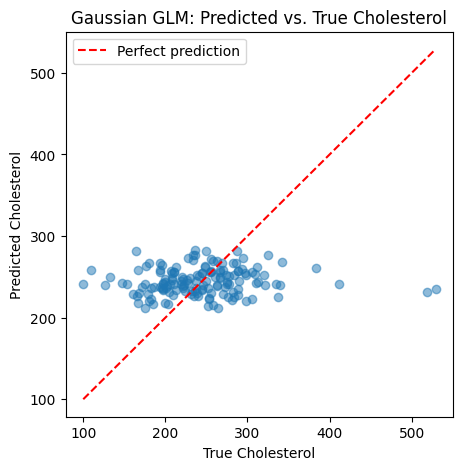

In [15]:
plt.figure(figsize=(5, 5))
plt.scatter(yg_test, yg_pred, alpha=0.5)
min_val, max_val = min(yg_test.min(), yg_pred.min()), max(yg_test.max(), yg_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")
plt.xlabel("True Cholesterol")
plt.ylabel("Predicted Cholesterol")
plt.title("Gaussian GLM: Predicted vs. True Cholesterol")
plt.legend()
plt.show()

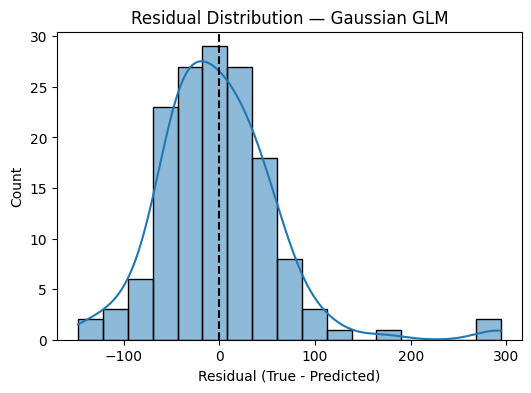

In [16]:
residuals = yg_test - yg_pred

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Residual (True - Predicted)")
plt.title("Residual Distribution — Gaussian GLM")
plt.show()

> 💡 **Intuition:** Residuals scattered roughly symmetrically around 0 support the modeling
> assumption $y\mid x \sim N(\mu,\sigma^2)$ — the theory assumed Gaussian *noise* around the true mean,
> and that's exactly what a well-behaved residual plot should look like.

### Interpret Coefficients (Gaussian GLM)

Because features are standardized, $\theta_j$ shows each feature's linear effect on predicted
cholesterol directly (not an odds-ratio effect, unlike the Bernoulli GLM below — this is the identity
canonical response function at work: $h_\theta(x)=\theta^Tx$, no sigmoid squashing).

In [17]:
gaussian_coefs = pd.DataFrame({
    "Feature": Xg_train_scaled.columns,
    "theta_j": gaussian_glm.coef_,
}).sort_values("theta_j", key=abs, ascending=False)

print("Intercept (theta_0):", gaussian_glm.intercept_)
gaussian_coefs.head(10)

Intercept (theta_0): 245.0503355704698


,Feature,theta_j
6,Sex_M,-9.253201
10,RestingECG_Normal,-6.475624
11,RestingECG_ST,-6.377257
1,RestingBP,5.948573
8,ChestPainType_NAP,-5.114820
13,ST_Slope_Flat,5.017354
9,ChestPainType_TA,-4.557731
2,FastingBS,3.828832
12,ExerciseAngina_Y,2.791226
14,ST_Slope_Up,2.107246


An R² in this range is modest — cholesterol in this dataset is only weakly explained by the other
clinical variables available, which is a realistic result (cholesterol depends heavily on diet, genetics,
and factors not captured here). This is not a sign of a coding error; it reflects a genuine limit on
how well a **linear** Gaussian GLM can explain this particular target from these particular features.

---
## 7. Part B — Bernoulli GLM: Predicting `HeartDisease` (Logistic Regression)

$$
y\mid x;\theta \sim \text{Bernoulli}(\phi), \qquad
h_\theta(x) = E[y\mid x;\theta] = \phi = \frac{1}{1+e^{-\theta^Tx}}
$$

Same GLM recipe as Part A, but with the **Bernoulli** exponential-family assumption instead of the
Gaussian — which is why the canonical response function here is the **sigmoid**, not the identity.
We now use all 918 patients (no rows need to be dropped — `HeartDisease` has no invalid values), and
impute the disguised-missing `Cholesterol`/`RestingBP` *feature* values instead of discarding rows.

In [18]:
df_bernoulli = df_encoded.copy()

# Here Cholesterol/RestingBP are FEATURES, not the target, so we impute rather than drop rows
for col in ["RestingBP", "Cholesterol"]:
    df_bernoulli[col] = df_bernoulli[col].fillna(df_bernoulli[col].median())

X_b = df_bernoulli.drop(columns=["HeartDisease"])
y_b = df_bernoulli["HeartDisease"]

print("Rows available for the Bernoulli GLM:", X_b.shape[0])

Rows available for the Bernoulli GLM: 918


In [19]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_b, y_b, test_size=0.2, random_state=RANDOM_STATE, stratify=y_b
)

print("Training examples:", Xb_train.shape[0])
print("Test examples:", Xb_test.shape[0])

Training examples: 734
Test examples: 184


### Why scale the features?

Unlike `LinearRegression`'s closed-form solution, `LogisticRegression` is fit with an **iterative**
optimizer that maximizes $\ell(\theta)$. Features on very different scales (e.g. `Age` vs. `Oldpeak`)
distort the shape of that optimization surface and slow convergence — standardizing puts every feature
on comparable footing, exactly as discussed in the theory's optimization section (Newton's method /
gradient ascent).

In [20]:
scaler_b = StandardScaler()
Xb_train_scaled = pd.DataFrame(
    scaler_b.fit_transform(Xb_train), columns=Xb_train.columns, index=Xb_train.index
)
Xb_test_scaled = pd.DataFrame(
    scaler_b.transform(Xb_test), columns=Xb_test.columns, index=Xb_test.index
)

### Model Implementation

`LogisticRegression().fit()` finds the $\theta$ that maximizes the Bernoulli log-likelihood
$\ell(\theta) = \sum_i y^{(i)}\log h_\theta(x^{(i)}) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))$ — the same
MLE principle as Part A, just under a different exponential-family assumption.

In [21]:
bernoulli_glm = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
bernoulli_glm.fit(Xb_train_scaled, yb_train)

print("Bernoulli GLM (Logistic Regression) trained.")
print("Number of parameters (theta):", bernoulli_glm.coef_.shape[1])

Bernoulli GLM (Logistic Regression) trained.
Number of parameters (theta): 15


In [22]:
yb_pred = bernoulli_glm.predict(Xb_test_scaled)
yb_prob = bernoulli_glm.predict_proba(Xb_test_scaled)[:, 1]

accuracy = accuracy_score(yb_test, yb_pred)
precision = precision_score(yb_test, yb_pred)
recall = recall_score(yb_test, yb_pred)
f1 = f1_score(yb_test, yb_pred)
roc_auc = roc_auc_score(yb_test, yb_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8913
Precision: 0.8942
Recall:    0.9118
F1-score:  0.9029
ROC-AUC:   0.9327


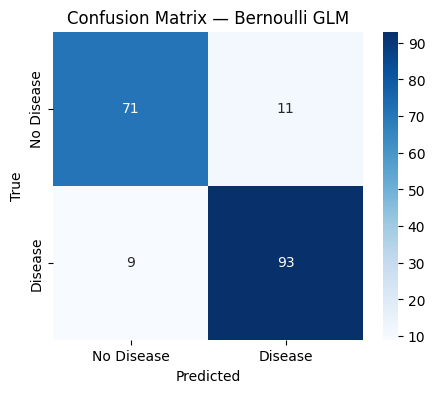

In [23]:
cm = confusion_matrix(yb_test, yb_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Bernoulli GLM")
plt.show()

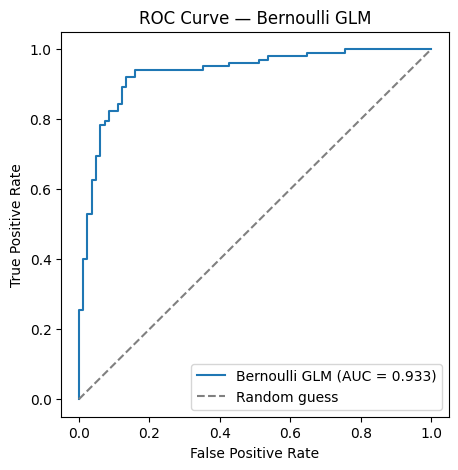

In [24]:
fpr, tpr, _ = roc_curve(yb_test, yb_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"Bernoulli GLM (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Bernoulli GLM")
plt.legend()
plt.show()

### Interpret Coefficients (Bernoulli GLM)

Here $\theta_j$ describes each feature's effect on the **log-odds** of heart disease (because of the
sigmoid canonical response function), not a direct additive effect on the outcome as in Part A.

In [25]:
bernoulli_coefs = pd.DataFrame({
    "Feature": Xb_train_scaled.columns,
    "theta_j": bernoulli_glm.coef_[0],
}).sort_values("theta_j", key=abs, ascending=False)

print("Intercept (theta_0):", bernoulli_glm.intercept_[0])
bernoulli_coefs.head(10)

Intercept (theta_0): 0.33757415332022983


,Feature,theta_j
14,ST_Slope_Up,-0.753877
8,ChestPainType_NAP,-0.726533
7,ChestPainType_ATA,-0.673642
6,Sex_M,0.573451
3,FastingBS,0.537593
13,ST_Slope_Flat,0.448219
12,ExerciseAngina_Y,0.409892
9,ChestPainType_TA,-0.326706
4,MaxHR,-0.282988
5,Oldpeak,0.236871


---
## 8. Comparing the Two GLMs Side by Side

| | Gaussian GLM (Part A) | Bernoulli GLM (Part B) |
|---|---|---|
| Target $y$ | `Cholesterol` (continuous) | `HeartDisease` (0/1) |
| Exponential family assumption | $y\mid x \sim N(\mu,\sigma^2)$ | $y\mid x \sim \text{Bernoulli}(\phi)$ |
| Natural parameter $\eta$ | $\mu$ | $\log(\phi/(1-\phi))$ |
| Canonical response $g(\eta)$ | Identity | Sigmoid |
| $h_\theta(x)$ | $\theta^Tx$ | $1/(1+e^{-\theta^Tx})$ |
| sklearn model | `LinearRegression` | `LogisticRegression` |
| Fit by | Minimizing squared error $\equiv$ maximizing Gaussian likelihood | Maximizing Bernoulli likelihood $\ell(\theta)$ |
| Coefficient meaning | Direct effect on $y$ | Effect on log-odds of $y=1$ |

Both models share the same underlying structure $h_\theta(x) = g(\theta^Tx)$ — this table is a direct,
concrete instance of the theory's claim that logistic regression and least squares are unified by a
single GLM framework, differing only in which exponential-family distribution is assumed for $y\mid x$.

## 9. Practical Experiment: Why the Right Canonical Response Function Matters

The theory chooses the response function $g$ based on the assumed distribution of $y\mid x$ — it is not
an arbitrary modeling choice. To make this concrete, we fit the **wrong** GLM assumption on the binary
target: use `LinearRegression` (the Gaussian/identity response) on `HeartDisease` instead of
`LogisticRegression` (the Bernoulli/sigmoid response), and inspect what goes wrong.

In [26]:
wrong_glm = LinearRegression()
wrong_glm.fit(Xb_train_scaled, yb_train)
wrong_predictions = wrong_glm.predict(Xb_test_scaled)

print("Range of predictions from LinearRegression on a 0/1 target:")
print(f"  min = {wrong_predictions.min():.3f}, max = {wrong_predictions.max():.3f}")
print(f"  fraction of predictions outside [0, 1]: "
      f"{np.mean((wrong_predictions < 0) | (wrong_predictions > 1)):.2%}")

print()
print("Compare to the Bernoulli GLM's predicted probabilities, which are always valid by construction:")
print(f"  min = {yb_prob.min():.3f}, max = {yb_prob.max():.3f}")

Range of predictions from LinearRegression on a 0/1 target:
  min = -0.146, max = 1.145
  fraction of predictions outside [0, 1]: 15.76%

Compare to the Bernoulli GLM's predicted probabilities, which are always valid by construction:
  min = 0.009, max = 0.991


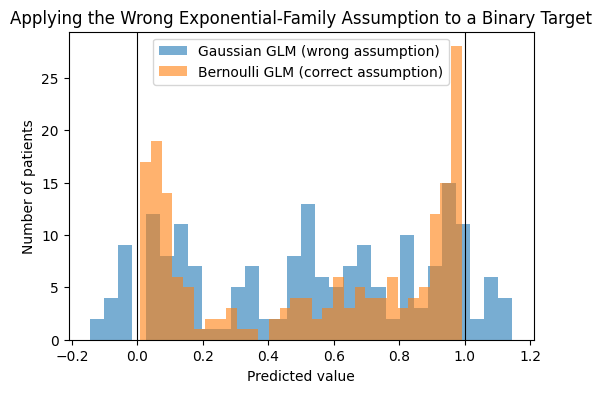

In [27]:
plt.figure(figsize=(6, 4))
plt.hist(wrong_predictions, bins=30, alpha=0.6, label="Gaussian GLM (wrong assumption)")
plt.hist(yb_prob, bins=30, alpha=0.6, label="Bernoulli GLM (correct assumption)")
plt.axvline(0, color="black", linewidth=0.8)
plt.axvline(1, color="black", linewidth=0.8)
plt.xlabel("Predicted value")
plt.ylabel("Number of patients")
plt.title("Applying the Wrong Exponential-Family Assumption to a Binary Target")
plt.legend()
plt.show()

> ⚠️ **Important:** The Gaussian GLM (`LinearRegression`) produces predictions outside $[0,1]$,
> which cannot be interpreted as probabilities of `HeartDisease=1`. This is exactly the problem the
> notes point out at the very start of the classification chapter: *"it doesn't make sense for
> $h_\theta(x)$ to take values larger than 1 or smaller than 0 when we know $y\in\{0,1\}$."* The
> Bernoulli GLM's sigmoid response function is not a cosmetic difference — it's a direct, necessary
> consequence of correctly modeling $y\mid x$ as Bernoulli instead of Gaussian.

## What We Learned

- **Problem solved:** demonstrated the GLM framework by fitting two different models on the same
  `heart.csv` dataset — a **Gaussian GLM** predicting continuous `Cholesterol`, and a **Bernoulli GLM**
  predicting binary `HeartDisease`.
- **Models used:** `sklearn.linear_model.LinearRegression` (Gaussian GLM / ordinary least squares) and
  `sklearn.linear_model.LogisticRegression` (Bernoulli GLM / logistic regression).
- **Theory in code:** both models are instances of $h_\theta(x) = g(\theta^Tx)$, differing only in the
  canonical response function $g$ dictated by the assumed exponential-family distribution of
  $y\mid x$ — identity for Gaussian, sigmoid for Bernoulli — exactly as derived in the notes.
- **Preprocessing required:** disguised missing values (`0` in `RestingBP`/`Cholesterol`) were handled
  differently depending on role — dropped when `Cholesterol` was the *target* (Part A, since there is
  no valid label to learn from), imputed with the training median when it was a *feature* (Part B); all
  categorical columns were one-hot encoded; features were standardized for both models; and all
  preprocessing was fit on training data only to avoid leakage.
- **Evaluation metrics:** MAE / RMSE / R² for the continuous target (Part A); accuracy, precision,
  recall, F1, and ROC-AUC for the binary target (Part B) — each chosen to match the type of $y$ implied
  by the GLM's exponential-family assumption.
- **Final result:** the side-by-side comparison table and the final experiment show concretely why the
  GLM framework's choice of response function is not arbitrary — using the Gaussian (identity) response
  on a binary target produces invalid, uninterpretable probability predictions, while the Bernoulli
  (sigmoid) response, derived directly from the exponential family, always produces valid probabilities
  in $[0,1]$.